In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [2]:
using Revise
using Newtrinos
using Newtrinos.osc

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x6e70319c1f9e48d9, 0xf013a04d5ba5fd2b, 0x991132363029dca8, 0x7588b554fd069fb5, 0x0c66a625d2b811d1, 0xd7aaa661c98c0a84, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [3]:

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   dayabay= Newtrinos.dayabay.configure(physics),
   gerda=Newtrinos.gerda.configure(physics)
);

par= Newtrinos.get_params(experiments)

[ Info: Loading dayabay data
[ Info: Loading Gerda data


(N = 100.0, m₀ = 0.001, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [4]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = ( r=31,  N=31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)

(N = Uniform{Float64}(a=1.0, b=100.0), m₀ = Uniform{Float64}(a=1.0e-6, b=1.0), r = Uniform{Float64}(a=0.0, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [5]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

Progress: 100%|█████████████████████████████████████████| Time: 1:11:30


NewtrinosResult((r = [0.0, 0.03333333333333333, 0.06666666666666667, 0.1, 0.13333333333333333, 0.16666666666666666, 0.2, 0.23333333333333334, 0.26666666666666666, 0.3  …  0.7, 0.7333333333333333, 0.7666666666666667, 0.8, 0.8333333333333334, 0.8666666666666667, 0.9, 0.9333333333333333, 0.9666666666666667, 1.0], N = [1.0, 4.3, 7.6, 10.9, 14.2, 17.5, 20.8, 24.1, 27.4, 30.7  …  70.3, 73.6, 76.9, 80.2, 83.5, 86.8, 90.10000000000001, 93.4, 96.7, 100.0]), (m₀ = [0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001; … ; 0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; … ; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.00247529

In [6]:
JLD2.@save "/home/sofialon/Newtrinos.jl/scan_final/gerda_dayabay_NNM_NO m0=0.001.jld2" result_NN

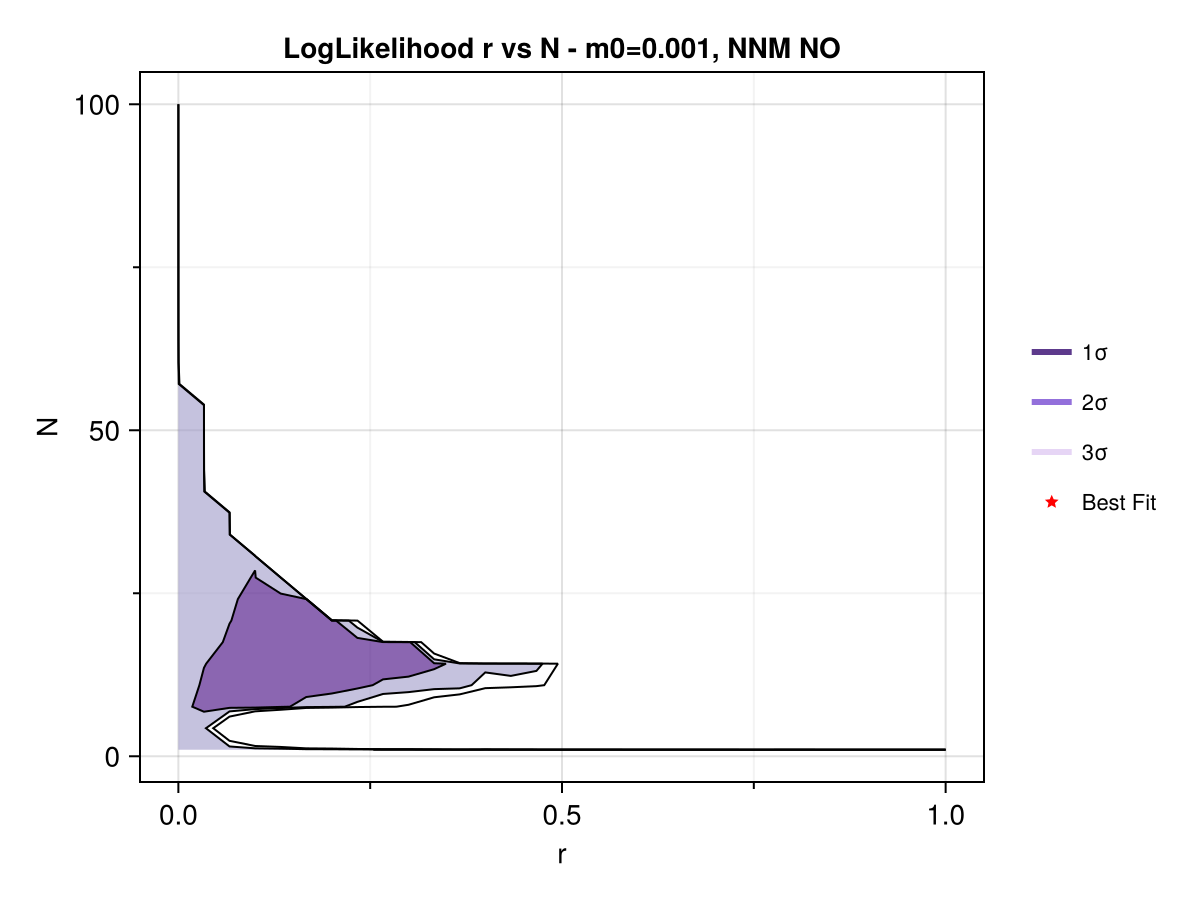

In [7]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood r vs N - m0=0.001, NNM NO")
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/legend1000_rm0_N100_NNM_NO.png", img)